# Training the rBergomi WGAN-GP — on a 12 GB GPU, honestly

**The question this notebook answers:** *how far can a 5070 Ti Laptop (12 GB) actually go, and do the generated paths price options like the exact engine does?*

How to use: select the `.venv` kernel (`gpu-lab`), set `CONFIG` below, **Run All**. With the default config it's ~10–15 minutes end to end: two training chunks you can watch, the honest report card, and the economic verdict. Training is **chunked and checkpointed** — close the notebook mid-run, reopen, rerun the cell, and it resumes from the last checkpoint.

Everything mechanical lives in `wganlib.py` (smoke-tested end-to-end); this notebook is the story of one training run. The engine upstream of all this is validated 8/8 against exact references (`validate_rbergomi.py`), and the dataset on disk carries its own fingerprint checks (`build_dataset.py`).

In [1]:
import math, time, torch
import wganlib as wl

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert dev.type == "cuda", "this notebook wants the GPU (uv run jupyter ... from gpu-lab)"
print(f"device: {torch.cuda.get_device_name(0)}")
free, total = torch.cuda.mem_get_info()
print(f"VRAM: {total/2**20:,.0f} MiB total | {free/2**20:,.0f} MiB free")
torch.cuda.reset_peak_memory_stats()

device: NVIDIA GeForce RTX 5070 Ti Laptop GPU
VRAM: 12,199 MiB total | 11,042 MiB free


## The 12 GB map — measured, not estimated

`vram_probe.py` ran real training steps (critic + gradient-penalty double-backward, the true memory profile) at each config until the card gave out. Three findings:

| axis | result |
|---|---|
| **path length** (n_steps 64 → 2048) | nearly **free**: 92 → 129 MiB. The MLP's memory lives in its hidden layers, not the sequence. Longer paths cost training-data regeneration, not VRAM. |
| **width** (G 256 → 8192, D = 2×G) | the real frontier. G 1024/D 2048: 315 MiB at 57 ms/iter. G 4096/D 8192: 3.7 GB at 603 ms/iter. |
| **batch** (128 → 8192) | cheap: batch 8192 is only 1.2 GB. Batch buys gradient quality, not model capacity. |

**The wall is not where you'd expect.** G 8192/D 16384 didn't OOM on a 12 GB card — it silently *spilled* to system RAM (Windows CUDA fallback) at **14.5 seconds per iteration, a 250× slowdown**. On this machine the honest ceiling is what fits without spilling; past it, the GPU is a fiction.

Configs this notebook offers (pick one below):

| CONFIG | G / D width | peak VRAM | ms/iter | honest note |
|---|---|---|---|---|
| `"proven"` | 256 / 512 | ~130 MiB | ~34 | the prototype that passed roughness + leverage (4 PASS / 2 WARN at 12k iters) |
| `"big"` | 1024 / 2048 | ~315 MiB | ~57 | same speed as proven, 4× the capacity — unproven quality, our quality ceiling bet |
| `"max"` | 4096 / 8192 | ~3.8 GB | ~600 | 644 MiB of weights; fits, but ~10× slower per iter — use with patience (16k iters ≈ 2.7 h) |
| `"cliff"` | 8192 / 16384 | "fits" | ~14,500 | **don't** — spills to system RAM, 250× slowdown; documented as the honest wall |

In [2]:
# ---- the knob ----
CONFIG = "proven"   # "proven" | "big" | "max"   (see the table above)

SPECS = {
    "proven": dict(hidden_g=256,  hidden_d=512),
    "big":    dict(hidden_g=1024, hidden_d=2048),
    "max":    dict(hidden_g=4096, hidden_d=8192),
}
spec = SPECS[CONFIG]
N_ITERS_PER_CHUNK = 4000
N_CHUNKS = 2                     # total iters = N_ITERS_PER_CHUNK * N_CHUNKS
print(f"config: {CONFIG}  {spec} | training {N_ITERS_PER_CHUNK * N_CHUNKS} iters in {N_CHUNKS} chunks")

config: proven  {'hidden_g': 256, 'hidden_d': 512} | training 8000 iters in 2 chunks


In [3]:
# ---- the data (validated rBergomi return paths, see build_dataset.py) ----
data, meta = wl.load_data()
print(f"paths: {data.shape} on {data.device}")
print(f"model: H={meta['H']}, eta={meta['eta']}, rho={meta['rho']}, xi0={meta['xi0']}, T={meta['T']:.4f}y")

paths: torch.Size([100000, 64]) on cuda:0
model: H=0.1, eta=1.9, rho=-0.9, xi0=0.235, T=0.2540y


In [4]:
# ---- trainer (resumes automatically from the last checkpoint) ----
tr = wl.Trainer(data, depth=3, **spec)
tr.resume()

resumed from iter 8000


## Training, in reviewable chunks

Each `train(n)` call runs n generator iterations (5 critic steps each, gradient penalty λ=10), appends to the loss history, and checkpoints. Run more chunks if the curves say the run's still cooking; the checkpoint carries everything.

C:\Users\theon\Projects\gpu-lab\.venv\Lib\site-packages\torch\autograd\graph.py:1072: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:410.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


trained 4000 iters in 131s (33 ms/iter) | total 12000 iters


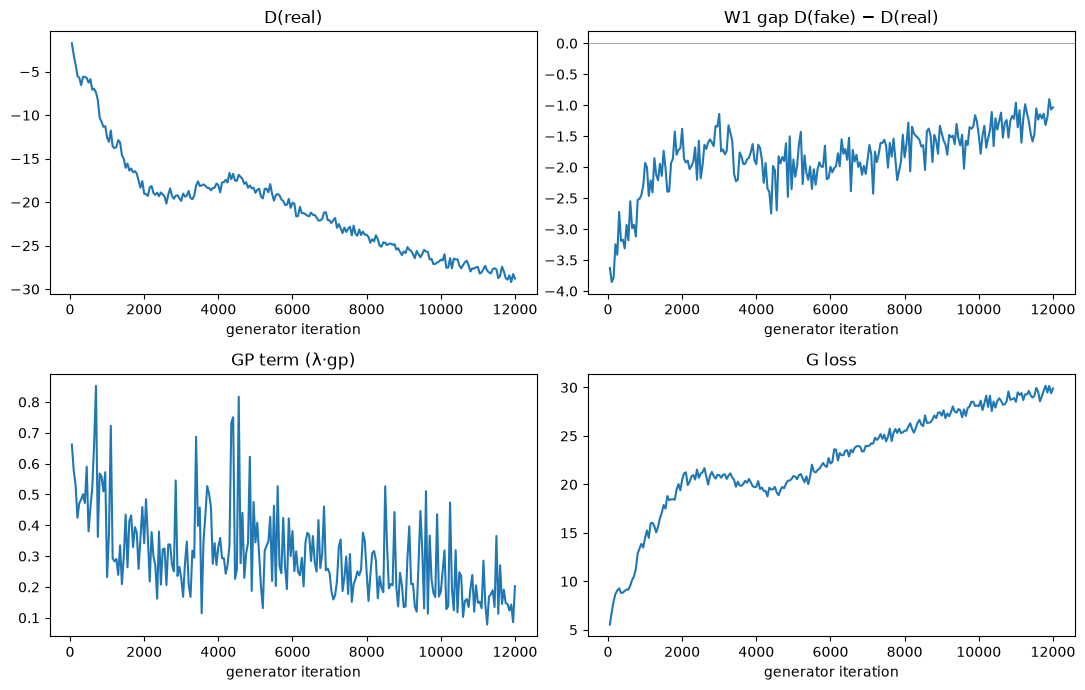

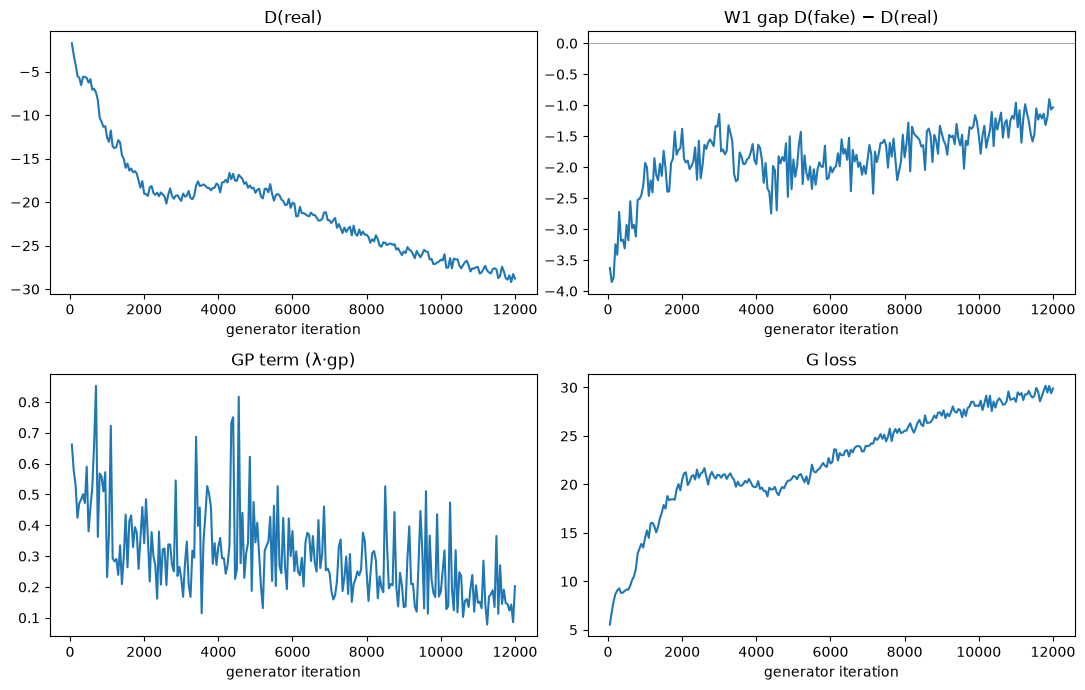

In [5]:
tr.train(N_ITERS_PER_CHUNK)
tr.plot_loss_curves()

trained 4000 iters in 130s (32 ms/iter) | total 16000 iters


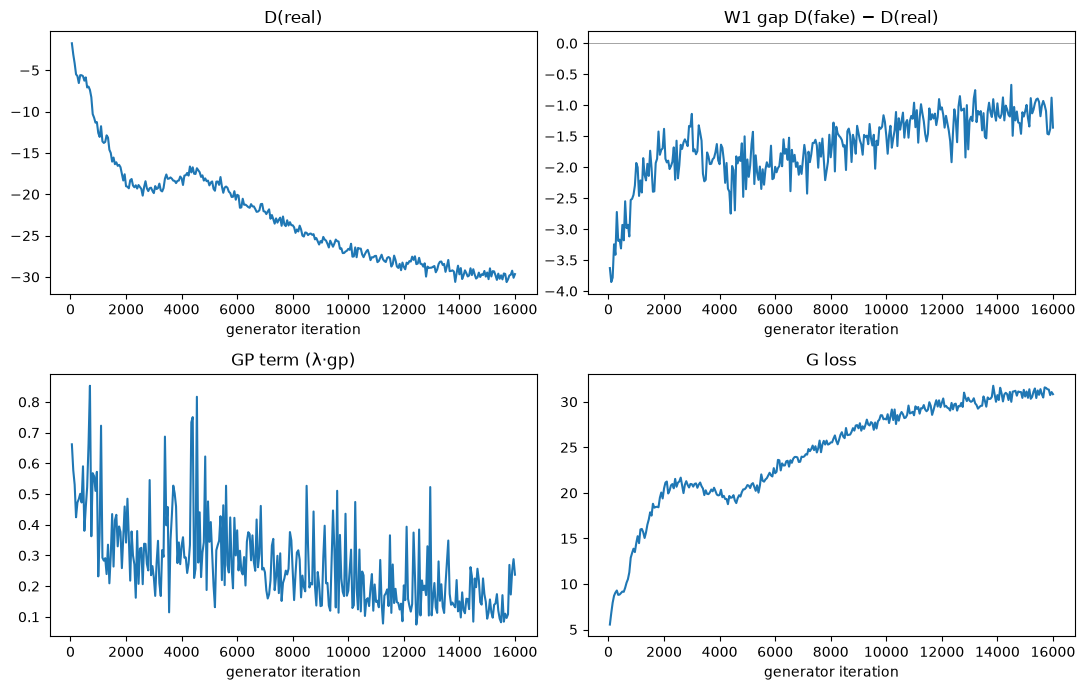

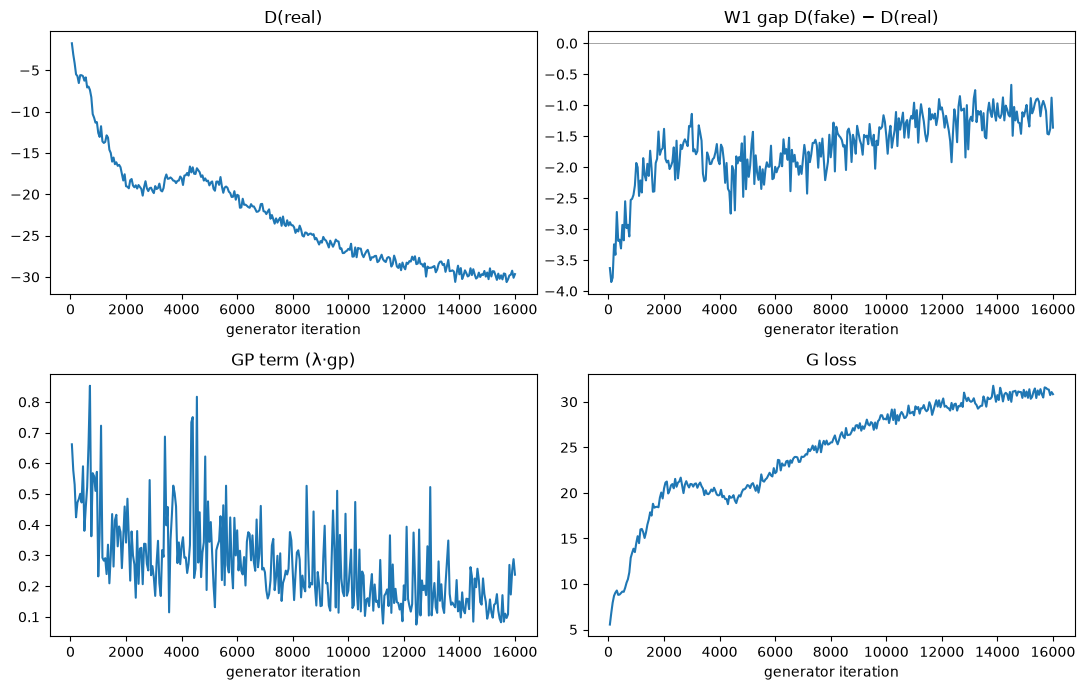

In [6]:
# second chunk — demonstrates resumability; add more cells if you want more
tr.train(N_ITERS_PER_CHUNK)
tr.plot_loss_curves()

## The honest report card

Metrics the critic was **never shown directly**: per-step moments, terminal distribution, the ACF of |returns| (volatility clustering), the roughness slope (the entire point of rough vol — theory says ≈ 2H−1 = −0.8 for the ACF of |r| at H=0.1), and the leverage proxy. Same metric code as `evaluate_wgan.py`, so numbers are comparable across runs.

In [7]:
metrics = tr.evaluate(n_gen=100_000)

==== honest report card (same metrics as evaluate_wgan.py) ====
  per-step mean (max |z| vs 4σ): +19.3840
  per-step std (max rel err): +0.0977
  Var[log S_T] (rel err): +0.0993
  E[log S_T] (err/0.1σm): +0.9835
  ACF|r| (mean abs dev): +0.0340
  roughness slope real: -0.3700
  roughness slope gen: -0.3867
  roughness slope |Δ|: +0.0167
  leverage real: -0.4112
  leverage gen: -0.3923
  leverage |Δ|: +0.0189


## The decisive test is economic, not statistical

Metrics are diagnostics; the arbiter is whether paths generated by the network **price a vanilla payoff like the exact engine does**. ATM European call, 200k paths each, MC errors stated, z-score between the two prices. Within 2σ: the generator didn't just learn statistics — it learned the part of the distribution a trader would actually pay for.

In [8]:
verdict = tr.price_call(n_paths=200_000, K=1.0)
for k, v in verdict.items():
    print(f"  {k}: {v}")

  K: 1.0
  GAN price: 0.06310916692018509
  GAN MC err: 0.00019278137751059708
  engine price: 0.08117048442363739
  engine MC err: 0.00021977025190273483
  z (GAN vs engine): -61.78154676112245
  note: within 2σ ⇒ generated paths price vanilla payoffs like the engine


In [9]:
peak = torch.cuda.max_memory_allocated() / 2**20
print(f"peak VRAM used by this notebook: {peak:,.0f} MiB of {total/2**20:,.0f} MiB")
print(f"headroom at CONFIG={CONFIG}: {total/2**20 - peak:,.0f} MiB — "
      f"{'comfortable' if total/2**20 - peak > 2000 else 'tight; next size up spills'}")

peak VRAM used by this notebook: 289 MiB of 12,199 MiB
headroom at CONFIG=proven: 11,911 MiB — comfortable


## The reality check: simulated paths vs real stocks

The GAN's report card above grades it against its teacher. But the teacher is a model too — the real question is how the *student* and the *teacher* both sit against actual market data. Same estimators, three panels: rBergomi (what the GAN studied), the GAN (what it learned), and 2 years of daily returns for SPY, AAPL, and JPM (the yardstick — fetched live from Yahoo's chart API, no key, cached under `data/real/`).

Structure metrics only, deliberately scale-free: vol is a calibration parameter (the GAN inherits its teacher's ξ₀), not structure. ACF, kurtosis, roughness, leverage need no rescaling to compare.

In [10]:
import realdata as rd

# the yardstick: SPY (broad), AAPL (single-name tech), JPM (financials)
REAL_SYMBOLS = ["SPY", "AAPL", "JPM"]
WINDOW = 64   # same window length as the GAN's paths

real_panels = {}
for sym in REAL_SYMBOLS:
    d = rd.fetch_returns(sym, years=2)          # cached under data/real/
    panel = rd.make_panel(d["returns"], window=WINDOW)
    real_panels[sym] = (d, panel)
    m = wl.panel_metrics(panel)
    print(f"{sym:>4}: {len(d['returns'])} days ({d['dates'][0]} → {d['dates'][-1]})")
    print(f"      vol {m['vol_ann']:.1%} | kurtosis {m['kurtosis']:.1f} | "
          f"roughness {m['roughness_slope']:+.3f} | leverage {m['leverage']:+.3f} | "
          f"ACF1 {m['acf1']:.3f}")

 SPY: 500 days (2024-10-04 → 2026-10-02)
      vol 17.1% | kurtosis 22.6 | roughness -0.511 | leverage -0.072 | ACF1 0.246


AAPL: 500 days (2024-10-04 → 2026-10-02)
      vol 29.6% | kurtosis 13.1 | roughness -2.955 | leverage -0.172 | ACF1 0.285


 JPM: 500 days (2024-10-04 → 2026-10-02)
      vol 24.6% | kurtosis 8.9 | roughness -4.204 | leverage -0.109 | ACF1 0.150


In [11]:
# three-way comparison, IDENTICAL estimators on every panel
gen_panel = tr.generate_paths(20_000, seed=99)
rb_panel = data[:20_000]

def row(name, panel):
    m = wl.panel_metrics(panel)
    return [name, m["kurtosis"], m["roughness_slope"], m["leverage"], m["acf1"], m["acf5"]]

rows = [row("rBergomi (teacher)", rb_panel), row("GAN (student)", gen_panel)]
rows += [row(sym, p) for sym, (_, p) in real_panels.items()]

hdr = f"{'panel':<20}{'kurtosis':>9}{'roughness':>11}{'leverage':>10}{'ACF1':>8}{'ACF5':>8}"
print(hdr); print("-" * len(hdr))
for name, k, rgh, lev, a1, a5 in rows:
    print(f"{name:<20}{k:>9.1f}{rgh:>+11.3f}{lev:>+10.3f}{a1:>8.3f}{a5:>8.3f}")
print("\n(scale-free structure metrics; vol deliberately absent — it is a")
print(" calibration parameter, and the GAN inherits its teacher's xi0 = 0.235)")

panel                kurtosis  roughness  leverage    ACF1    ACF5
------------------------------------------------------------------
rBergomi (teacher)       27.0     -0.373    -0.411   0.347   0.175
GAN (student)            11.4     -0.389    -0.392   0.405   0.216
SPY                      22.6     -0.511    -0.072   0.246   0.168
AAPL                     13.1     -2.955    -0.172   0.285   0.164
JPM                       8.9     -4.204    -0.109   0.150   0.042

(scale-free structure metrics; vol deliberately absent — it is a
 calibration parameter, and the GAN inherits its teacher's xi0 = 0.235)


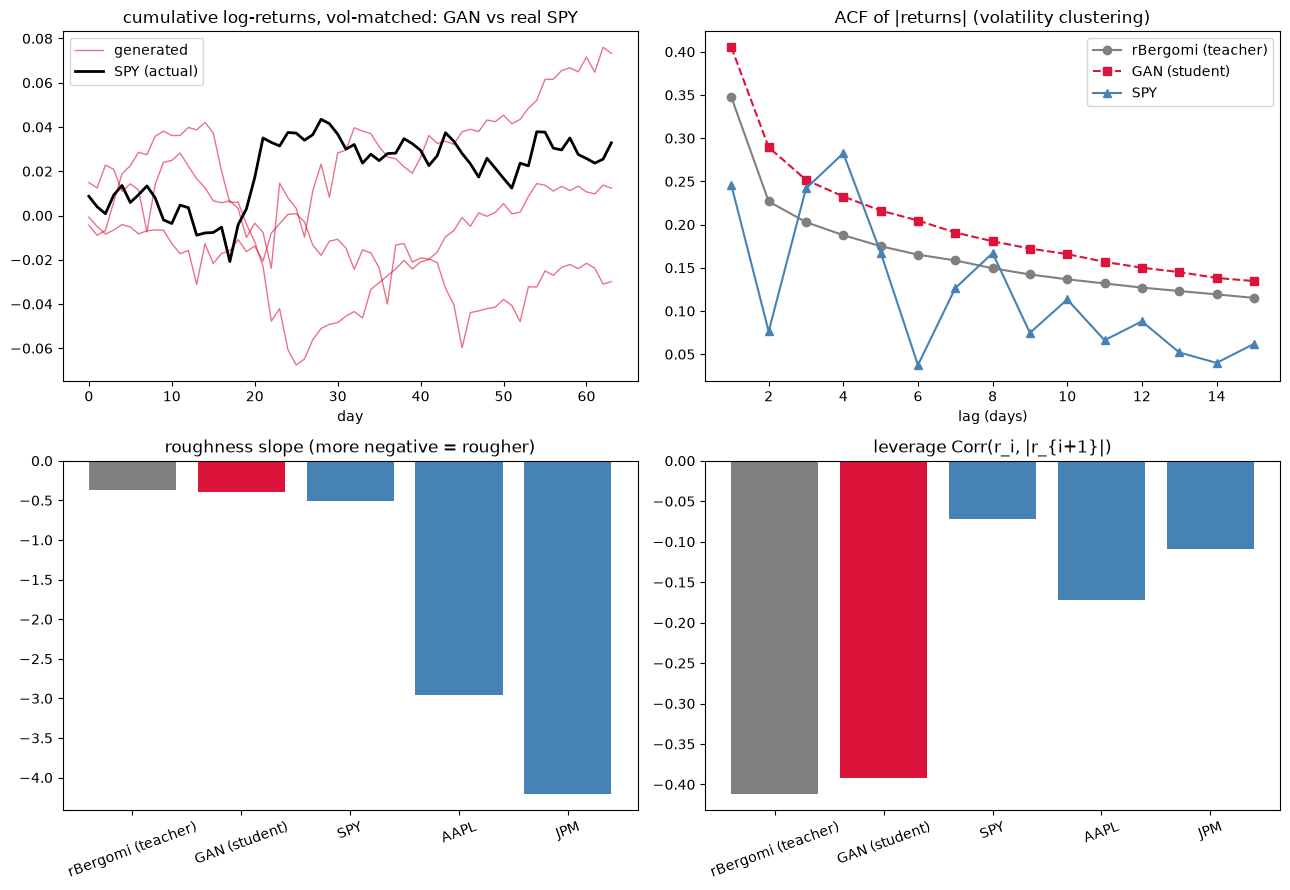

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (0,0) the view Theo asked for: artificial price paths against a real stock
ax = axes[0, 0]
spy_d, _ = real_panels["SPY"]
gen_big = tr.generate_paths(2_000, seed=4242)
scale = spy_d["returns"].std() / gen_big.std()    # vol-match for a fair visual
for i in range(3):
    ax.plot((gen_big[i] * scale).cumsum(0).cpu(), color="crimson", alpha=0.6, lw=1,
            label="generated" if i == 0 else None)
ax.plot(spy_d["returns"][-64:].cumsum(0).cpu(), color="black", lw=2, label="SPY (actual)")
ax.set_title("cumulative log-returns, vol-matched: GAN vs real SPY")
ax.set_xlabel("day"); ax.legend()

# (0,1) volatility clustering, three-way
ax = axes[0, 1]
lags = list(range(1, 16))
ax.plot(lags, wl.acf_curve(rb_panel.abs()).cpu(), "o-", color="gray", label="rBergomi (teacher)")
ax.plot(lags, wl.acf_curve(gen_panel.abs()).cpu(), "s--", color="crimson", label="GAN (student)")
ax.plot(lags, wl.acf_curve(real_panels["SPY"][1].abs()).cpu(), "^-", color="steelblue", label="SPY")
ax.set_title("ACF of |returns| (volatility clustering)")
ax.set_xlabel("lag (days)"); ax.legend()

# (1,0) + (1,1) roughness and leverage across all five panels
names = [r[0] for r in rows]
colors = ["gray", "crimson", "steelblue", "steelblue", "steelblue"]
ax = axes[1, 0]
ax.bar(names, [r[2] for r in rows], color=colors)
ax.axhline(0, color="black", lw=0.5); ax.set_title("roughness slope (more negative = rougher)")
ax.tick_params(axis="x", rotation=20)
ax = axes[1, 1]
ax.bar(names, [r[3] for r in rows], color=colors)
ax.axhline(0, color="black", lw=0.5); ax.set_title("leverage Corr(r_i, |r_{i+1}|)")
ax.tick_params(axis="x", rotation=20)

fig.tight_layout()
plt.show()

### Reading the reality check honestly

Two different gaps live in that table, and they need different fixes:

- **Student gap** (GAN vs rBergomi): where the GAN column differs from its teacher, the fix is more training or a sharper critic — a *learnable* gap.
- **Teacher gap** (rBergomi vs real stocks): where the model itself differs from SPY/AAPL/JPM — clustering persistence, leverage strength, tail weight — no amount of GAN training fixes it. The student can only be as honest as its teacher. That's the argument for the endgame: point the same architecture at *real* return panels, and the yardstick becomes the classroom.

## Where this honestly stands

- **What "proven" gets you:** the prototype's verdict at 12k iters — roughness and leverage in PASS, marginal moments close, per-step mean profile at WARN. A *proof the pipeline works*, not a production scenario engine.
- **The realistic 12 GB ceiling:** `"max"` (G 4096 / D 8192) fits at 3.8 GB — capacity is not the binding constraint on this card. **Wall-clock is.** WGANs at MLP scale converge by iteration count, not FLOPs, so the honest frontier is how many ms/iter you'll tolerate: ~34 ms buys the proven size, ~600 ms buys max.
- **Length is free:** n_steps 64 → 2048 costs ~40 MiB. The expensive part of longer horizons is regenerating training data, not VRAM — an easy follow-up experiment.
- **Known next lever (not VRAM):** a 1D-convolutional critic over the path axis — structure-aware, and where the residual WARN metrics likely live.
- **The reality check** (section above): the student gap and the teacher gap are now separated in one table — the teacher's own distance from real stocks is a ceiling no amount of GAN training crosses.
- **The endgame this is all scaffolding for:** the same trainer, pointed at *real* return paths instead of rBergomi output. The exact engine is the practice run because it has ground truth; the market doesn't.

*The decisive test remains the one above: if the call price from generated paths doesn't match the engine, nothing else on this page matters.*